# 14. Classification — Multi-Layer Perceptron (MLP)

**Scratch**: Full forward pass + backpropagation + Adam optimiser (NumPy only)  
**sklearn**: `MLPClassifier` with tuned architecture

### Theory

A Multi-Layer Perceptron is a **feedforward neural network** with one or more hidden layers. Each neuron computes a weighted sum of its inputs, applies a non-linear **activation function**, and passes the result forward.

**Forward pass** for layer $l$:
$$z^{(l)} = W^{(l)} a^{(l-1)} + b^{(l)}, \quad a^{(l)} = \text{ReLU}(z^{(l)})$$

Output layer uses **sigmoid** for binary classification:
$$\hat{p} = \sigma(z^{(L)}) = \frac{1}{1 + e^{-z^{(L)}}}$$

**Loss** — Binary cross-entropy:
$$\mathcal{L} = -\frac{1}{n}\sum_{i=1}^{n}\left[y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i)\right]$$

**Backpropagation** — Chain rule applied layer by layer from output to input:
$$\frac{\partial \mathcal{L}}{\partial W^{(l)}} = \frac{\partial \mathcal{L}}{\partial z^{(l)}} \cdot (a^{(l-1)})^\top$$

**Architecture chosen**: `input(10) → Dense(128, ReLU) → Dropout(0.3) → Dense(64, ReLU) → Dropout(0.3) → Dense(1, Sigmoid)`  
Two hidden layers with decreasing width give capacity without severe overfitting on this dataset.

## 1. Imports, Setup & Shared Utilities

In [2]:
import os, json, pickle, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, roc_curve,
    accuracy_score, precision_score, f1_score
)

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR      = os.path.abspath(os.path.join(os.getcwd(), '..'))
TRAIN_FILE    = os.path.join(BASE_DIR, 'data', 'final_training_data_classification_train.csv')
TEST_FILE     = os.path.join(BASE_DIR, 'data', 'final_training_data_classification_test.csv')
FEATURES_FILE = os.path.join(BASE_DIR, 'data', 'selected_features_classification.json')
SCALER_FILE   = os.path.join(BASE_DIR, 'models', 'scaler_classification.pkl')
MODELS_DIR    = os.path.join(BASE_DIR, 'models')
RESULTS_DIR   = os.path.join(BASE_DIR, 'results')
PLOTS_DIR     = os.path.join(BASE_DIR, 'plots')
RESULTS_CSV   = os.path.join(RESULTS_DIR, 'classification_results.csv')

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(PLOTS_DIR,   exist_ok=True)

# ── Shared utility: compute all classification metrics ────────────────────────
def compute_metrics(model_name, y_true, y_pred, y_prob=None):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    accuracy    = (tp + tn) / (tp + tn + fp + fn)
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1          = 2*precision*sensitivity / (precision+sensitivity) if (precision+sensitivity) > 0 else 0.0
    auc         = roc_auc_score(y_true, y_prob) if y_prob is not None else float('nan')
    print(f"\n{'='*55}\n  {model_name}\n{'='*55}")
    print(f"  Confusion Matrix : TN={tn}  FP={fp}  FN={fn}  TP={tp}")
    print(f"  Accuracy         : {accuracy:.4f}")
    print(f"  Precision        : {precision:.4f}")
    print(f"  Sensitivity      : {sensitivity:.4f}")
    print(f"  Specificity(TNR) : {specificity:.4f}")
    print(f"  F1-Score         : {f1:.4f}")
    print(f"  ROC-AUC          : {auc:.4f}")
    print(f"{'='*55}")
    return {
        'model': model_name,
        'accuracy':    round(accuracy, 4),
        'precision':   round(precision, 4),
        'sensitivity': round(sensitivity, 4),
        'specificity': round(specificity, 4),
        'tnr':         round(specificity, 4),
        'f1':          round(f1, 4),
        'roc_auc':     round(auc, 4) if not np.isnan(auc) else None,
        'tp': int(tp), 'tn': int(tn), 'fp': int(fp), 'fn': int(fn),
        'recall': round(sensitivity, 4),
    }

# ── Shared utility: append result row to CSV ──────────────────────────────────
def save_results(metrics_dict):
    row = pd.DataFrame([metrics_dict])
    if os.path.exists(RESULTS_CSV):
        existing = pd.read_csv(RESULTS_CSV)
        existing = existing[existing['model'] != metrics_dict['model']]
        row = pd.concat([existing, row], ignore_index=True)
    row.to_csv(RESULTS_CSV, index=False)
    print(f"Results saved to {RESULTS_CSV}")

# ── Shared utility: plot confusion matrix ─────────────────────────────────────
def plot_confusion_matrix(y_true, y_pred, model_name, save_path):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Down (0)', 'Up (1)'],
                yticklabels=['Down (0)', 'Up (1)'], ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {model_name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

print("Utilities loaded.")

Utilities loaded.


## 2. Load & Scale Data

In [3]:
with open(FEATURES_FILE) as f:
    features = json.load(f)

with open(SCALER_FILE, 'rb') as f:
    scaler = pickle.load(f)

train_df = pd.read_csv(TRAIN_FILE)
test_df  = pd.read_csv(TEST_FILE)

X_train = scaler.transform(train_df[features].values)
y_train = train_df['target_class'].values
X_test  = scaler.transform(test_df[features].values)
y_test  = test_df['target_class'].values

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"Features ({len(features)}): {features}")
print(f"Class balance (train) — Up: {y_train.mean()*100:.1f}%  Down: {(1-y_train.mean())*100:.1f}%")

X_train: (60260, 10)  |  X_test: (10635, 10)
Features (10): ['close_position', 'return_lag_1h', 'log_return_1h', 'gk_avg_3h', 'log_return_3h', 'gk_lag_1h', 'hl_range_pct', 'trade_intensity', 'atr_lag_3h', 'log_return_6h']
Class balance (train) — Up: 50.9%  Down: 49.1%


/Users/mihiniboteju/cryptoflow/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/mihiniboteju/cryptoflow/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## 3. MLP — Scratch

**Architecture**: `10 → 128 (ReLU) → 64 (ReLU) → 1 (Sigmoid)`  
**Regularisation**: Dropout (training only) + L2 weight decay via Adam  
**Optimiser**: Adam with mini-batches  
**Early stopping**: patience on validation loss (last 10% of train, temporal split)

In [4]:
class MLPScratch:
    """
    Multi-Layer Perceptron from scratch using NumPy.
    Architecture: input → [Dense(ReLU) → Dropout] × n_hidden → Dense(Sigmoid)
    Optimiser: Adam with mini-batches.
    """

    def __init__(self, layer_sizes, dropout_rate=0.3, lr=0.001,
                 weight_decay=1e-4, seed=42):
        """
        layer_sizes : list of ints, e.g. [10, 128, 64, 1]
                      first = input_dim, last = output_dim
        """
        np.random.seed(seed)
        self.layer_sizes  = layer_sizes
        self.dropout_rate = dropout_rate
        self.lr           = lr
        self.weight_decay = weight_decay
        self.n_layers     = len(layer_sizes) - 1   # number of weight matrices

        # He initialisation for ReLU layers
        self.W = []
        self.b = []
        for i in range(self.n_layers):
            fan_in = layer_sizes[i]
            scale  = np.sqrt(2.0 / fan_in)
            self.W.append(np.random.randn(layer_sizes[i+1], layer_sizes[i]) * scale)
            self.b.append(np.zeros((layer_sizes[i+1], 1)))

        # Adam moment estimates
        self._mW = [np.zeros_like(w) for w in self.W]
        self._vW = [np.zeros_like(w) for w in self.W]
        self._mb = [np.zeros_like(b) for b in self.b]
        self._vb = [np.zeros_like(b) for b in self.b]
        self._t  = 0

    # ── Activations ─────────────────────────────────────────────────────────
    @staticmethod
    def _relu(z):        return np.maximum(0, z)
    @staticmethod
    def _relu_grad(z):   return (z > 0).astype(float)
    @staticmethod
    def _sigmoid(z):     return 1 / (1 + np.exp(-np.clip(z, -30, 30)))

    # ── Forward pass ─────────────────────────────────────────────────────────
    def _forward(self, X, training=True):
        """
        X : (n_features, batch_size)
        Returns output probabilities (1, batch_size) and cache for backprop.
        """
        cache = []          # stores (A_prev, Z, mask) per layer
        A = X
        for l in range(self.n_layers):
            Z = self.W[l] @ A + self.b[l]         # linear
            is_output = (l == self.n_layers - 1)
            if is_output:
                A_next = self._sigmoid(Z)          # output: sigmoid
                mask   = None
            else:
                A_next = self._relu(Z)             # hidden: ReLU
                # Inverted dropout (scale up during training)
                if training and self.dropout_rate > 0:
                    mask   = (np.random.rand(*A_next.shape) > self.dropout_rate)
                    A_next = A_next * mask / (1 - self.dropout_rate)
                else:
                    mask   = None
            cache.append((A, Z, mask))
            A = A_next
        return A, cache        # A = (1, batch_size)

    # ── Backward pass ─────────────────────────────────────────────────────────
    def _backward(self, y, y_hat, cache):
        """
        y     : (1, batch_size)  — true labels
        y_hat : (1, batch_size)  — predicted probabilities
        """
        m = y.shape[1]
        dA = (y_hat - y) / m      # gradient of BCE w.r.t. sigmoid output

        grads_W, grads_b = [], []
        for l in reversed(range(self.n_layers)):
            A_prev, Z, mask = cache[l]
            is_output = (l == self.n_layers - 1)

            if is_output:
                dZ = dA                        # sigmoid gradient already in dA
            else:
                dZ = dA * self._relu_grad(Z)   # ReLU gradient
                if mask is not None:
                    dZ = dZ * mask / (1 - self.dropout_rate)

            dW = dZ @ A_prev.T + self.weight_decay * self.W[l]  # L2 penalty
            db = dZ.sum(axis=1, keepdims=True)
            dA = self.W[l].T @ dZ              # pass gradient to previous layer

            grads_W.insert(0, dW)
            grads_b.insert(0, db)

        return grads_W, grads_b

    # ── Adam update ───────────────────────────────────────────────────────────
    def _adam_step(self, grads_W, grads_b):
        b1, b2, eps = 0.9, 0.999, 1e-8
        self._t += 1
        for l in range(self.n_layers):
            for param, grad, m, v in [
                ('W', grads_W[l], self._mW[l], self._vW[l]),
                ('b', grads_b[l], self._mb[l], self._vb[l]),
            ]:
                m[:] = b1*m + (1-b1)*grad
                v[:] = b2*v + (1-b2)*grad**2
                m_hat = m / (1 - b1**self._t)
                v_hat = v / (1 - b2**self._t)
                update = self.lr * m_hat / (np.sqrt(v_hat) + eps)
                if param == 'W':
                    self.W[l] -= update
                else:
                    self.b[l] -= update

    # ── Training ──────────────────────────────────────────────────────────────
    def fit(self, X_train, y_train, X_val, y_val,
            epochs=100, batch_size=256, patience=10, verbose=True):
        n = X_train.shape[0]
        train_losses, val_losses = [], []
        best_val, best_W, best_b, patience_ctr = np.inf, None, None, 0

        for epoch in range(1, epochs+1):
            # Mini-batch SGD
            idx = np.random.permutation(n)
            X_s, y_s = X_train[idx], y_train[idx]
            epoch_loss = 0.0
            for start in range(0, n, batch_size):
                Xb = X_s[start:start+batch_size].T   # (features, batch)
                yb = y_s[start:start+batch_size].reshape(1, -1)
                y_hat, cache = self._forward(Xb, training=True)
                loss = -np.mean(yb*np.log(y_hat+1e-9) + (1-yb)*np.log(1-y_hat+1e-9))
                epoch_loss += loss * len(yb[0])
                gW, gb = self._backward(yb, y_hat, cache)
                self._adam_step(gW, gb)
            train_losses.append(epoch_loss / n)

            # Validation loss (no dropout)
            y_val_hat, _ = self._forward(X_val.T, training=False)
            yv = y_val.reshape(1, -1)
            val_loss = -np.mean(yv*np.log(y_val_hat+1e-9) + (1-yv)*np.log(1-y_val_hat+1e-9))
            val_losses.append(val_loss)

            if val_loss < best_val:
                best_val     = val_loss
                best_W       = [w.copy() for w in self.W]
                best_b       = [b.copy() for b in self.b]
                patience_ctr = 0
            else:
                patience_ctr += 1

            if verbose and (epoch % 10 == 0 or epoch == 1):
                print(f"  Epoch {epoch:3d}/{epochs} | "
                      f"train_loss={train_losses[-1]:.4f} | "
                      f"val_loss={val_loss:.4f} | patience={patience_ctr}/{patience}")

            if patience_ctr >= patience:
                print(f"  Early stopping at epoch {epoch}.")
                break

        # Restore best weights
        self.W = best_W
        self.b = best_b
        return train_losses, val_losses

    # ── Inference ─────────────────────────────────────────────────────────────
    def predict_proba(self, X):
        y_hat, _ = self._forward(X.T, training=False)
        return y_hat.flatten()

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)


print("MLPScratch class defined.")
print("Architecture: 10 → 128 (ReLU, Dropout) → 64 (ReLU, Dropout) → 1 (Sigmoid)")

MLPScratch class defined.
Architecture: 10 → 128 (ReLU, Dropout) → 64 (ReLU, Dropout) → 1 (Sigmoid)


Train: (54234, 10)  |  Val: (6026, 10)  |  Test: (10635, 10)

Training MLP Scratch ...
  Epoch   1/150 | train_loss=0.7246 | val_loss=0.6880 | patience=0/15
  Epoch  10/150 | train_loss=0.6848 | val_loss=0.6880 | patience=9/15
  Epoch  20/150 | train_loss=0.6833 | val_loss=0.6884 | patience=4/15
  Epoch  30/150 | train_loss=0.6828 | val_loss=0.6881 | patience=14/15
  Early stopping at epoch 31.
Done in 4.7s


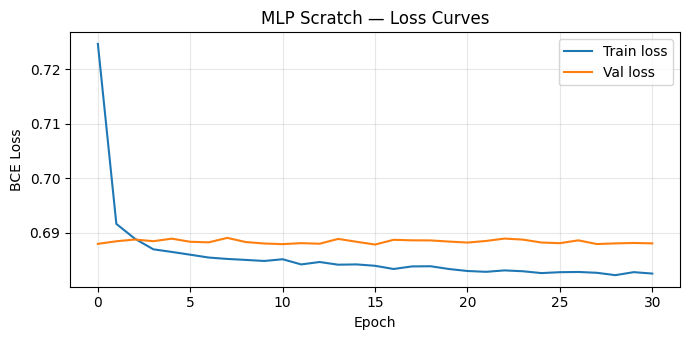

In [5]:
# ── Temporal validation split — last 10% of train ─────────────────────────────
val_size = int(len(X_train) * 0.10)
X_tr, X_val_s = X_train[:-val_size], X_train[-val_size:]
y_tr, y_val_s = y_train[:-val_size], y_train[-val_size:]

print(f"Train: {X_tr.shape}  |  Val: {X_val_s.shape}  |  Test: {X_test.shape}")

# ── Train scratch MLP ─────────────────────────────────────────────────────────
mlp_scratch = MLPScratch(
    layer_sizes   = [10, 128, 64, 1],
    dropout_rate  = 0.3,
    lr            = 0.001,
    weight_decay  = 1e-4,
    seed          = 42
)

print("\nTraining MLP Scratch ...")
t0 = time.time()
train_losses, val_losses = mlp_scratch.fit(
    X_tr, y_tr, X_val_s, y_val_s,
    epochs=150, batch_size=256, patience=15, verbose=True
)
print(f"Done in {time.time()-t0:.1f}s")

# Loss curve
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(train_losses, label='Train loss')
ax.plot(val_losses,   label='Val loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('BCE Loss')
ax.set_title('MLP Scratch — Loss Curves'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


  MLP Scratch
  Confusion Matrix : TN=2459  FP=2822  FN=2200  TP=3154
  Accuracy         : 0.5278
  Precision        : 0.5278
  Sensitivity      : 0.5891
  Specificity(TNR) : 0.4656
  F1-Score         : 0.5568
  ROC-AUC          : 0.5415


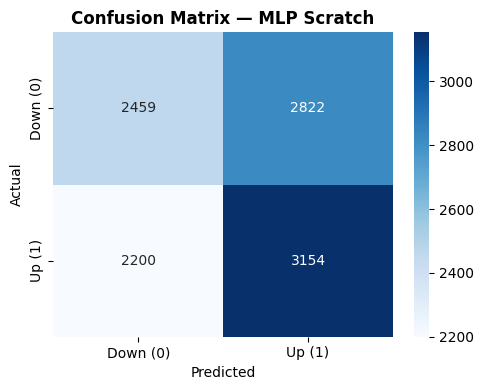

Saved: /Users/mihiniboteju/cryptoflow/plots/mlp_scratch_confusion_matrix.png
Model saved → models/mlp_scratch.pkl
Results saved to /Users/mihiniboteju/cryptoflow/results/classification_results.csv


In [6]:
# ── Evaluate scratch MLP ──────────────────────────────────────────────────────
scratch_prob = mlp_scratch.predict_proba(X_test)
scratch_pred = mlp_scratch.predict(X_test)

metrics_scratch = compute_metrics('MLP Scratch', y_test, scratch_pred, scratch_prob)

plot_confusion_matrix(
    y_test, scratch_pred,
    'MLP Scratch',
    os.path.join(PLOTS_DIR, 'mlp_scratch_confusion_matrix.png')
)

# Save model
with open(os.path.join(MODELS_DIR, 'mlp_scratch.pkl'), 'wb') as f:
    pickle.dump(mlp_scratch, f)
print("Model saved → models/mlp_scratch.pkl")

save_results(metrics_scratch)

## 4. MLP — sklearn (`MLPClassifier`)

**Architecture**: `(128, 64)` hidden layers, ReLU activation, Adam optimiser  
**Regularisation**: L2 alpha=0.0001, early stopping on validation loss

Training sklearn MLPClassifier ...
Done in 3.3s  |  Stopped at iteration: 27


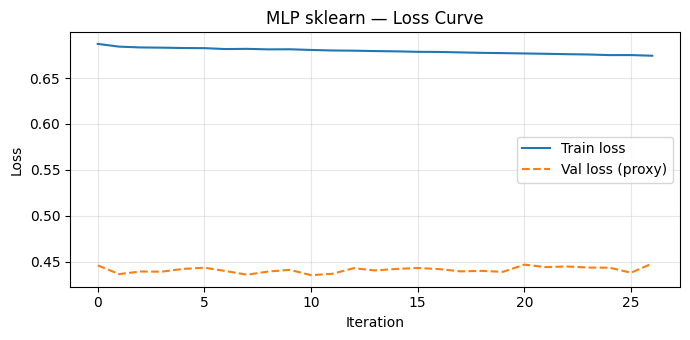

In [7]:
# ── Train sklearn MLP ─────────────────────────────────────────────────────────
mlp_sklearn = MLPClassifier(
    hidden_layer_sizes  = (128, 64),
    activation          = 'relu',
    solver              = 'adam',
    alpha               = 1e-4,          # L2 regularisation
    batch_size          = 256,
    learning_rate_init  = 0.001,
    max_iter            = 200,
    early_stopping      = True,
    validation_fraction = 0.10,
    n_iter_no_change    = 15,            # patience
    random_state        = 42,
    verbose             = False,
)

print("Training sklearn MLPClassifier ...")
t0 = time.time()
mlp_sklearn.fit(X_train, y_train)
print(f"Done in {time.time()-t0:.1f}s  |  Stopped at iteration: {mlp_sklearn.n_iter_}")

# Loss curve
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(mlp_sklearn.loss_curve_,       label='Train loss')
if mlp_sklearn.validation_scores_ is not None:
    # sklearn reports validation *score* (accuracy), invert to get loss proxy
    ax.plot([1-s for s in mlp_sklearn.validation_scores_], label='Val loss (proxy)', linestyle='--')
ax.set_xlabel('Iteration'); ax.set_ylabel('Loss')
ax.set_title('MLP sklearn — Loss Curve'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


  MLP sklearn
  Confusion Matrix : TN=2582  FP=2699  FN=2288  TP=3066
  Accuracy         : 0.5311
  Precision        : 0.5318
  Sensitivity      : 0.5727
  Specificity(TNR) : 0.4889
  F1-Score         : 0.5515
  ROC-AUC          : 0.5423


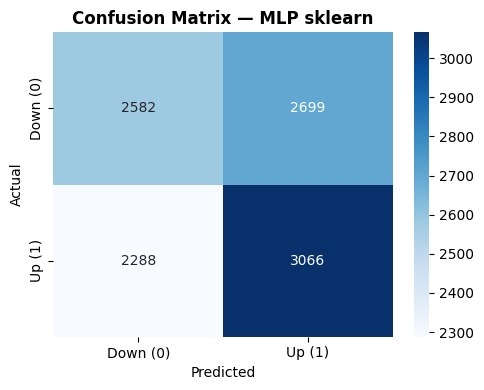

Saved: /Users/mihiniboteju/cryptoflow/plots/mlp_sklearn_confusion_matrix.png
Model saved → models/mlp_sklearn.pkl
Results saved to /Users/mihiniboteju/cryptoflow/results/classification_results.csv


In [8]:
# ── Evaluate sklearn MLP ──────────────────────────────────────────────────────
sklearn_prob = mlp_sklearn.predict_proba(X_test)[:, 1]
sklearn_pred = mlp_sklearn.predict(X_test)

metrics_sklearn = compute_metrics('MLP sklearn', y_test, sklearn_pred, sklearn_prob)

plot_confusion_matrix(
    y_test, sklearn_pred,
    'MLP sklearn',
    os.path.join(PLOTS_DIR, 'mlp_sklearn_confusion_matrix.png')
)

# Save model
with open(os.path.join(MODELS_DIR, 'mlp_sklearn.pkl'), 'wb') as f:
    pickle.dump(mlp_sklearn, f)
print("Model saved → models/mlp_sklearn.pkl")

save_results(metrics_sklearn)

## 5. ROC Curve Comparison & Summary

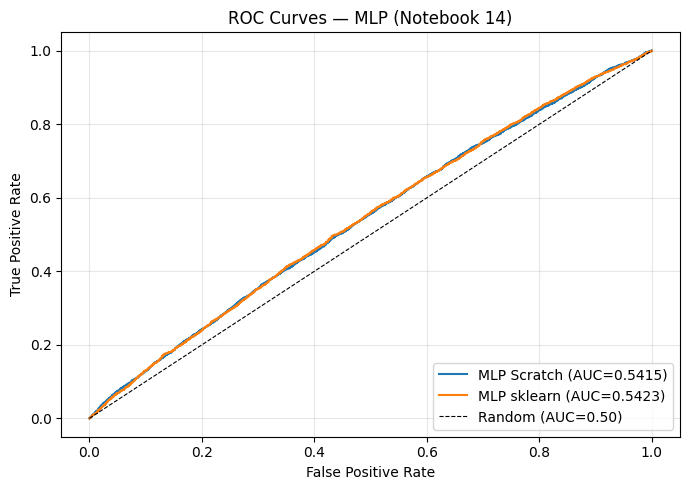


── Notebook 14 Summary ──────────────────────────────────────
      model  accuracy  precision  sensitivity  specificity     f1  roc_auc
MLP Scratch    0.5278     0.5278       0.5891       0.4656 0.5568   0.5415
MLP sklearn    0.5311     0.5318       0.5727       0.4889 0.5515   0.5423

── All Models (classification_results.csv) ──────────────────
                                  model  accuracy  precision  sensitivity  specificity     f1  roc_auc
                Majority Class Baseline    0.5034     0.5034       1.0000       0.0000 0.6697   0.5000
          Logistic Regression (Scratch)    0.5236     0.5265       0.5334       0.5137 0.5300   0.5388
          Logistic Regression (sklearn)    0.5247     0.5275       0.5347       0.5145 0.5311   0.5386
                Decision Tree (Scratch)    0.5296     0.5327       0.5334       0.5257 0.5331   0.5295
        Decision Tree sklearn (depth=3)    0.5308     0.5305       0.5921       0.4687 0.5596   0.5359
                Random Forest (

In [9]:
# ── ROC curves ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
for label, y_prob in [
    ('MLP Scratch',  scratch_prob),
    ('MLP sklearn',  sklearn_prob),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{label} (AUC={auc_val:.4f})')

ax.plot([0,1],[0,1],'k--', linewidth=0.8, label='Random (AUC=0.50)')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — MLP (Notebook 14)')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'mlp_roc_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
display_cols = ['model','accuracy','precision','sensitivity','specificity','f1','roc_auc']
summary = pd.DataFrame([metrics_scratch, metrics_sklearn])
print('\n── Notebook 14 Summary ──────────────────────────────────────')
print(summary[display_cols].to_string(index=False))

print('\n── All Models (classification_results.csv) ──────────────────')
all_results = pd.read_csv(RESULTS_CSV)
print(all_results[display_cols].to_string(index=False))